# Literature Review
- This dataset contains 1000 rows and 11 columns representing BGIS match performance data.
Each row corresponds to a single match entry with a unique match_id.
The dataset includes categorical features like region, map, and stage for grouping analysis.
It also has a time feature match_date for trend analysis.
Key performance variables include kills, damage, placement, and points.
The data is clean with no missing values or duplicate rows.
Some outliers are present in kills and damage but may represent real gameplay extremes.
match_number is not unique, so it should not be used as a primary key.
The region column is important for comparing performance across different regions.
Overall, the dataset is well-structured and suitable for exploratory data analysis (EDA).

 source 1: https://liquipedia.net/

source 2 : https://www.battlegroundsmobileindia.com/

## ***Points Determination Factors in BGIS Dataset***

- In this BGIS dataset, the points scored by teams are determined by multiple performance-related factors. These factors explain how teams earn points during matches.

## **Main Factors Affecting Points**

### 1. Placement (Rank in Match)
- Placement is the most important factor in determining points. Teams that finish in higher positions (such as 1st or 2nd) receive more points, while teams finishing at lower ranks (like 15th or 16th) receive fewer points.

### 2. Kills
- Kills directly contribute to the total points. Each kill adds a fixed number of points, so teams with more kills generally score higher.

### 3. Damage
- Damage is not always directly counted in points, but it has a strong relationship with kills. Higher damage usually leads to more kills, which increases points indirectly.

### 4. Stage (Qualifier, Quarterfinal, etc.)
- Different stages represent different levels of competition. In later stages, matches are more competitive, which can influence how points are distributed.

### 5. Map
- Different maps affect gameplay style. Some maps encourage aggressive gameplay, leading to more kills and higher points.

### 6. Team Performance (team_name)
- Strong teams consistently perform better in terms of placement and kills, which results in higher points.

### 7. Region
- Region can reflect the competition level. Some regions may have stronger teams, which can influence overall performance and points.

# ***issues***
- The points column is unreliable because it was incorrectly calculated and therefore removed.

- The placement column shows extreme/repetitive values since in a single match the maximum placement score is limited (10), which reduces variability and can distort analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
import pandas as pd
df=pd.read_csv('bgis_2026_data_1000_rows.csv')
df 

,match_id,match_date,match_number,team_name,region,map,stage,placement,kills,damage,points
0,BGIS26-M0001,2026-01-01,72,Global Esports,North,Miramar,Group Stage,11,5,239,18
1,BGIS26-M0002,2026-01-01,92,Phoenix Esports,South,Sanhok,Qualifier 2,15,4,55,8
2,BGIS26-M0003,2026-01-01,8,Insane Esports,Northeast,Sanhok,Quarterfinal,16,1,116,4
3,BGIS26-M0004,2026-01-01,95,Medal Esports,Northeast,Vikendi,Qualifier 1,1,8,275,43
4,BGIS26-M0005,2026-01-01,3,Mortal Squad,Central,Sanhok,Quarterfinal,10,6,190,23
...,...,...,...,...,...,...,...,...,...,...,...
995,BGIS26-M0996,2026-04-30,23,Phoenix Esports,East,Sanhok,Group Stage,7,3,215,24
996,BGIS26-M0997,2026-04-30,18,GodLike,North,Miramar,Qualifier 2,15,7,185,11
997,BGIS26-M0998,2026-04-30,1,Phoenix Esports,West,Erangel,Semifinal,3,7,230,37
998,BGIS26-M0999,2026-04-30,35,FS Esports,South,Erangel,Semifinal,15,7,235,11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   match_id      1000 non-null   object
 1   match_date    1000 non-null   object
 2   match_number  1000 non-null   int64 
 3   team_name     1000 non-null   object
 4   region        1000 non-null   object
 5   map           1000 non-null   object
 6   stage         1000 non-null   object
 7   placement     1000 non-null   int64 
 8   kills         1000 non-null   int64 
 9   damage        1000 non-null   int64 
 10  points        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df.describe()

,match_number,placement,kills,damage,points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,61.191000,8.751000,5.177000,188.367000,23.121000
std,33.837782,4.644413,2.559731,64.768474,10.251412
min,1.000000,1.000000,0.000000,20.000000,2.000000
25%,31.000000,5.000000,3.000000,142.000000,15.000000
50%,62.000000,9.000000,5.000000,190.000000,23.000000
75%,89.000000,13.000000,7.000000,232.000000,31.000000
max,120.000000,16.000000,14.000000,389.000000,46.000000


In [6]:
df = df[df['map'] != 'Vikendi'].copy()
df.shape

(862, 11)

The Vikendi map was removed from the dataset because it is not part of the standard competitive tournament map pool. Including it could introduce bias in the analysis, as gameplay dynamics (player behavior, survival rate, and win patterns) differ across maps. To ensure consistency and relevance to competitive scenarios, only maps used in tournaments were retained

In [7]:
df.drop('points', axis=1, inplace=True, errors='ignore')
df.shape

(862, 10)

- The points column was removed because it was being generated incorrectly from the placement and kill values

In [8]:
unique_stages = df['stage'].unique()
stage_counts = df['stage'].value_counts()
unique_stages
stage_counts

stage
Group Stage     255
Qualifier 1     191
Qualifier 2     143
Quarterfinal    132
Semifinal        92
Final            49
Name: count, dtype: int64

In [9]:


# Step 3: Keep only top 10 placements
df = df[df['placement'] <= 10].copy()

# Step 4: Create new column (total_points)
df['total_points'] = df['kills'] + df['placement']

# Step 5: Check result
print(df.head())
print(df.shape)

# Step 6: Save cleaned dataset
df.to_csv("cleaned_data.csv", index=False)

       match_id  match_date  match_number         team_name     region  \
4  BGIS26-M0005  2026-01-01             3      Mortal Squad    Central   
5  BGIS26-M0006  2026-01-01            67               TWM  Northeast   
6  BGIS26-M0007  2026-01-01           108    Global Esports       East   
8  BGIS26-M0009  2026-01-01            81  Hyderabad Hydras    Central   
9  BGIS26-M0010  2026-01-02           100     Medal Esports       East   

       map         stage  placement  kills  damage  total_points  
4   Sanhok  Quarterfinal         10      6     190            16  
5    Rondo         Final          2      7     302             9  
6  Erangel  Quarterfinal          2      6     144             8  
8  Miramar   Qualifier 1          3      8     302            11  
9  Miramar   Qualifier 1         10      5     183            15  
(514, 11)


- Rows with placement greater than 10 were removed because placement 10 was considered the maximum valid value in a single match. The remaining higher values were treated as outliers and
We created a new feature called total_points, which contains the sum of placement and kill values.

In [10]:
df.head()


,match_id,match_date,match_number,team_name,region,map,stage,placement,kills,damage,total_points
4,BGIS26-M0005,2026-01-01,3,Mortal Squad,Central,Sanhok,Quarterfinal,10,6,190,16
5,BGIS26-M0006,2026-01-01,67,TWM,Northeast,Rondo,Final,2,7,302,9
6,BGIS26-M0007,2026-01-01,108,Global Esports,East,Erangel,Quarterfinal,2,6,144,8
8,BGIS26-M0009,2026-01-01,81,Hyderabad Hydras,Central,Miramar,Qualifier 1,3,8,302,11
9,BGIS26-M0010,2026-01-02,100,Medal Esports,East,Miramar,Qualifier 1,10,5,183,15


- The Vikendi map was removed as it was not considered part of the main tournament maps.
- The points column was dropped because it was incorrectly calculated.
- Rows with placement greater than 10 were removed, keeping only top 10 finishes.
- A new column total_points was created by adding kills and placement.
- Finally, the cleaned dataset was saved as cleaned_data.csv.

# ***Univariate Analysis***

## ***kill Distribution***

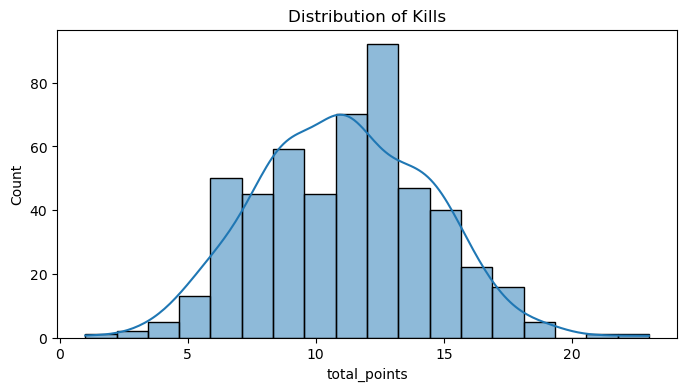

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['total_points'], kde=True)
plt.title("Distribution of Kills")
plt.show()


***finding***:The graph shows how total points are spread out. Most teams score between 10 and 14 points, which means average performance is common. Very low and very high scores happen less often. The data looks balanced without any strong tilt. Overall, team performance is steady and consistent.

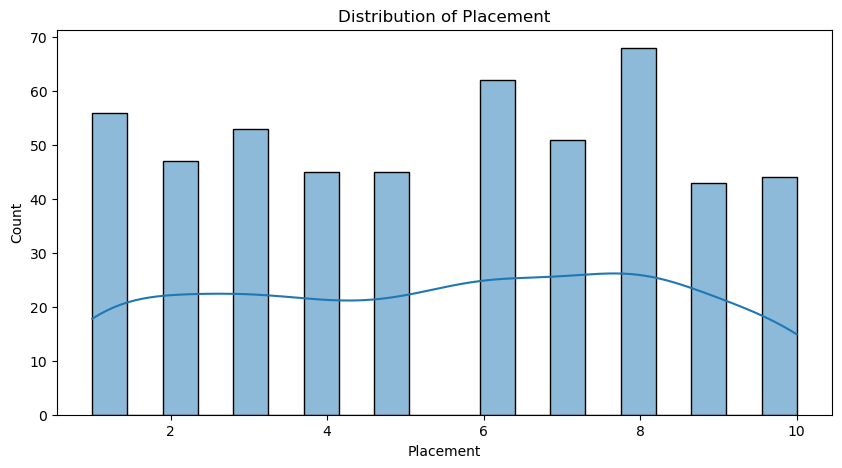

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(df['placement'], bins=20, kde=True)

plt.title("Distribution of Placement")
plt.xlabel("Placement")
plt.ylabel("Count")

plt.show()

The graph shows how placements are distributed among teams. Most placement values are spread across all positions, with no single position dominating strongly. Some positions like 6 to 8 appear slightly more frequent. Lower and higher placements occur less often but are still present. Overall, placements are fairly evenly distributed without any strong pattern.

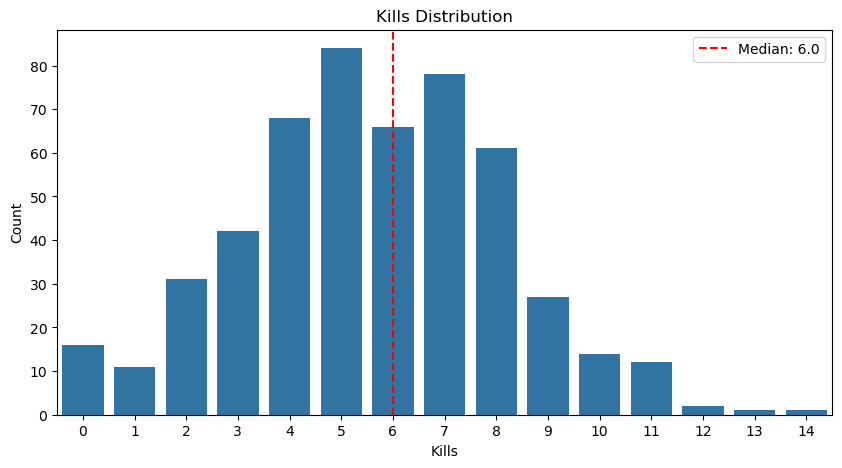

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(x='kills', data=df)

# Calculate median
median_val = df['kills'].median()

# Add vertical line (red color)
plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val}')

plt.title("Kills Distribution")
plt.xlabel("Kills")
plt.ylabel("Count")

plt.legend()
plt.show()

The graph shows how kills are distributed among teams. Most teams get around 5 to 7 kills, with the median at 6, showing average performance. Very low kills (0–2) and very high kills (10+) are less common. The data is slightly spread but still centered around the middle. Overall, most teams achieve a moderate number of kills.

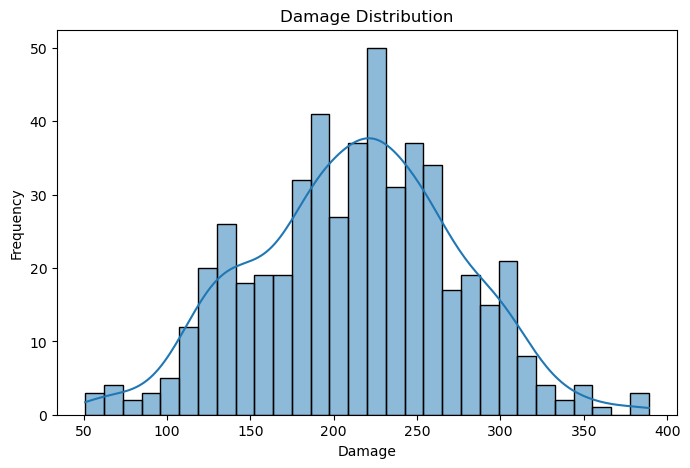

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['damage'], bins=30, kde=True)

plt.title("Damage Distribution")
plt.xlabel("Damage")
plt.ylabel("Frequency")

plt.show()

The graph shows how damage is distributed among teams. Most teams deal medium damage, with values concentrated in the middle range. Very low and very high damage values are less common. The shape looks like a bell curve, meaning the data is fairly balanced. Overall, most teams perform at an average damage level.

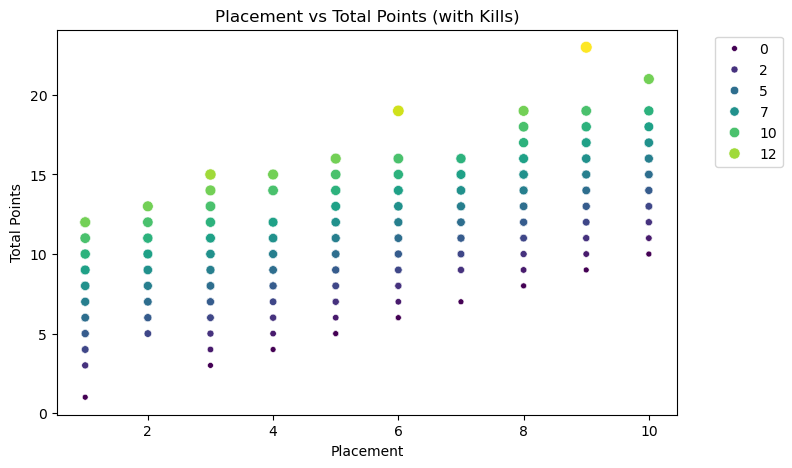

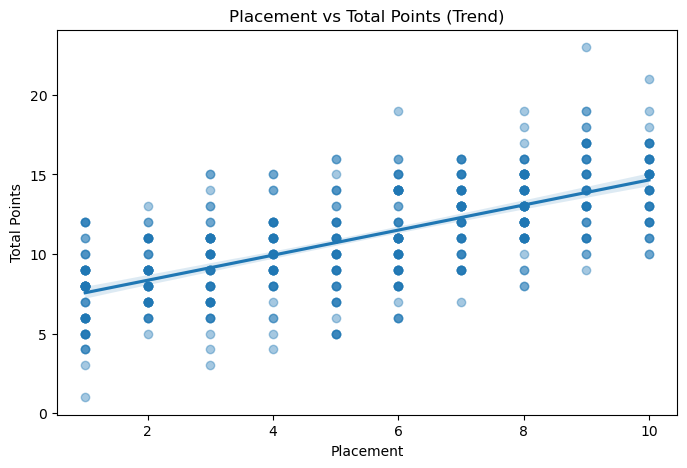

Correlation Matrix:
               placement  total_points     kills
placement      1.000000      0.672884 -0.238268
total_points   0.672884      1.000000  0.558116
kills         -0.238268      0.558116  1.000000


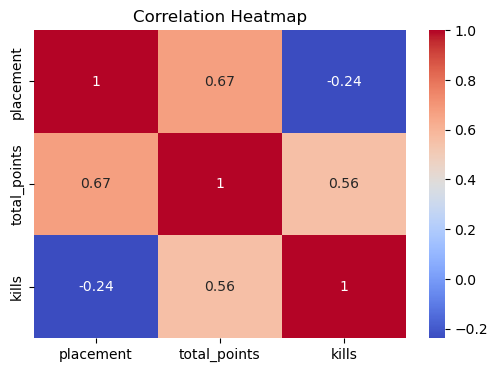

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create total_points
# -----------------------------
df['total_points'] = df['kills'] + df['placement']

# -----------------------------
# 2. Scatter Plot (kills added as hue + size)
# -----------------------------
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='placement',
    y='total_points',
    hue='kills',          # color based on kills
    size='kills',         # size based on kills
    palette='viridis'
)

plt.title("Placement vs Total Points (with Kills)")
plt.xlabel("Placement")
plt.ylabel("Total Points")

plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

# -----------------------------
# 3. Regression Plot
# -----------------------------
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='placement',
    y='total_points',
    scatter_kws={'alpha':0.4}
)

plt.title("Placement vs Total Points (Trend)")
plt.xlabel("Placement")
plt.ylabel("Total Points")

plt.show()

# -----------------------------
# 4. Correlation Matrix (kills added)
# -----------------------------
corr = df[['placement','total_points','kills']].corr()
print("Correlation Matrix:\n", corr)

# -----------------------------
# 5. Heatmap for better visualization
# -----------------------------
plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

- This graph shows placements from 1 to 10 and total points from about 1 to 23.
Each dot is a player/team, and colors show kills from 0 to 12.
As placement increases, total points also increase.
More kills give higher points, usually above 15–20.

- This heatmap shows the relationship between placement, total points, and kills.
Placement and total points have a positive relation (0.67), meaning better placement gives more points.
Kills and total points also have a positive relation (0.56), so more kills increase points.
Placement and kills have a slight negative relation (-0.24), meaning higher placement usually has fewer kills.

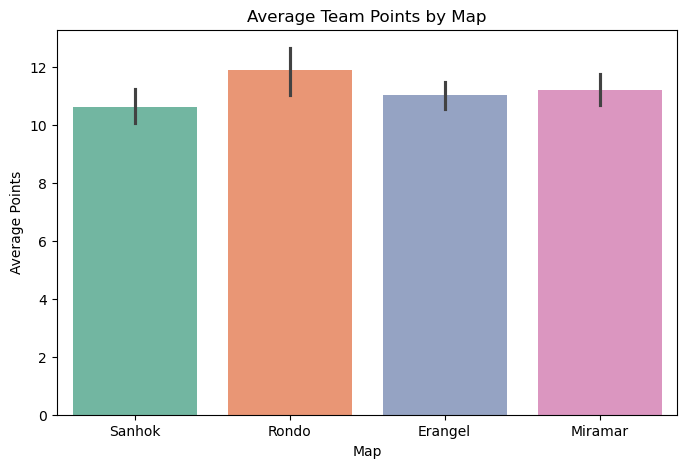

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="map",
    y="total_points",
    hue="map",              # each map gets different color
    palette="Set2",         # you can change palette
    legend=False            # remove extra legend (optional)
)

plt.title("Average Team Points by Map")
plt.xlabel("Map")
plt.ylabel("Average Points")

plt.show()

- Among all maps, Rondo has the highest average points (around 12), while Sanhok has the lowest (around 10.5).
Erangel and Miramar have similar performance, with average points close to 11–11.3.
Overall, teams perform slightly better on Rondo compared to other maps.

In [17]:
map_team_avg = df.groupby(['map', 'team_name'])['total_points'].mean().reset_index()

best_team_per_map = map_team_avg.loc[
    map_team_avg.groupby('map')['total_points'].idxmax()
]

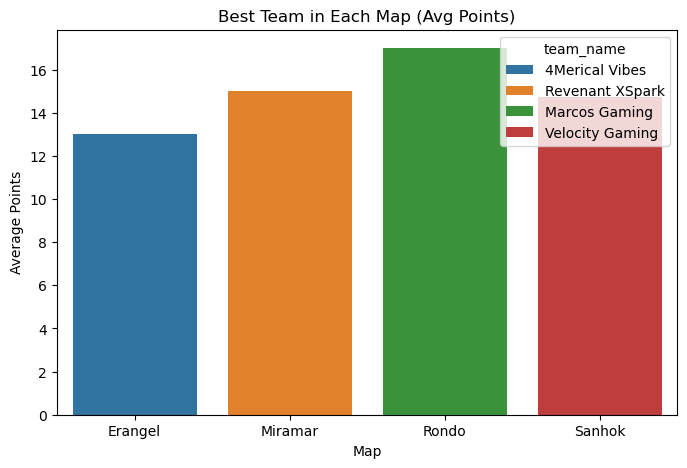

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=best_team_per_map,
    x='map',
    y='total_points',
    hue='team_name'
)

plt.title("Best Team in Each Map (Avg Points)")
plt.xlabel("Map")
plt.ylabel("Average Points")

plt.show()

- Erangel me best team 4Merical Vibes hai, avg ~13 points
- Miramar me Revenant Xspark top hai, avg ~15 points
- Rondo me Marcos Gaming sabse aage hai, avg ~17 points (highest)
- Sanhok me Velocity Gaming best hai, avg ~14 points

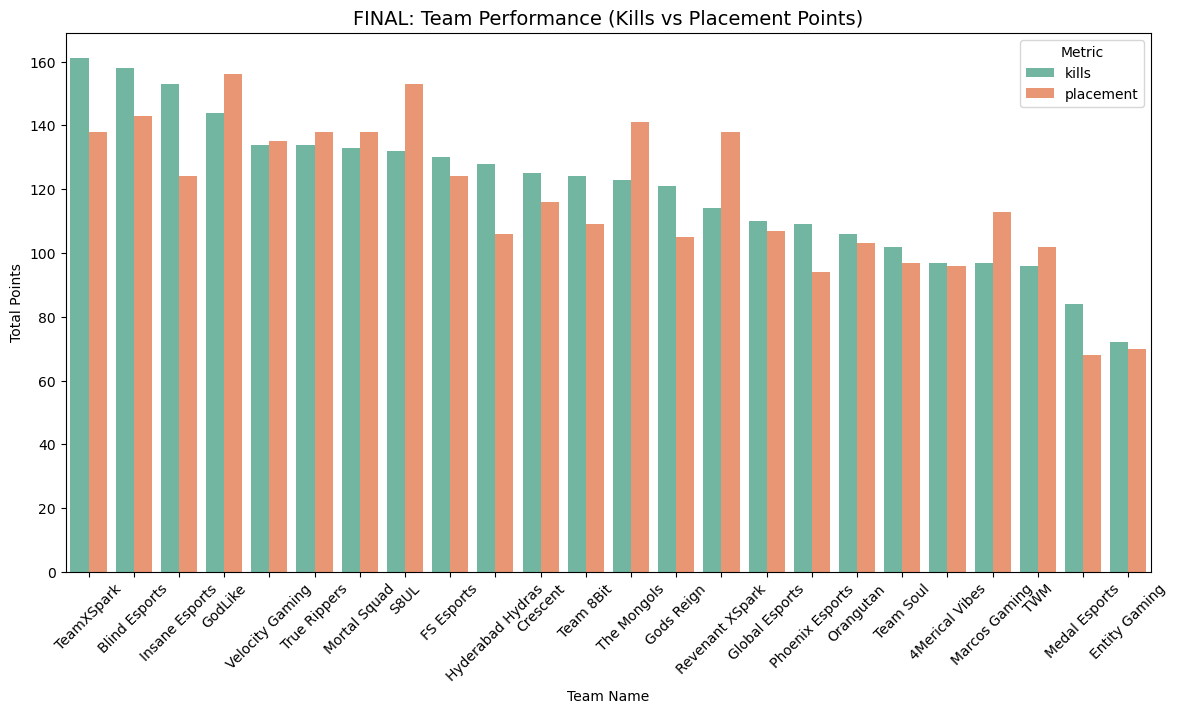

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Team-wise summary
# -----------------------------
team_stats = df.groupby('team_name')[['kills', 'placement']].sum().reset_index()

# Sorting (by kills)
team_stats = team_stats.sort_values(by='kills', ascending=False)

# -----------------------------
# 2. Melt data for combined graph
# -----------------------------
df_melt = team_stats.melt(
    id_vars='team_name',
    value_vars=['kills', 'placement'],
    var_name='metric',
    value_name='value'
)

# -----------------------------
# 3. Colorful Final Graph
# -----------------------------
plt.figure(figsize=(14,7))

sns.barplot(
    data=df_melt,
    x='team_name',
    y='value',
    hue='metric',
    palette='Set2'
)

plt.title("FINAL: Team Performance (Kills vs Placement Points)", fontsize=14)
plt.xlabel("Team Name")
plt.ylabel("Total Points")
plt.xticks(rotation=45)
plt.legend(title="Metric")

plt.show()


This graph compares kills and placement points of different teams.

The teams on the left side have the highest points, so they performed better overall.
TeamXSpark and Blind Esports look very strong in kills, while GodLike and S8UL are strong in placement points.  
The teams on the right side, like Medal Esports and Entity Gaming, have the lowest points, so their performance is weaker.  
Overall, the graph shows that top teams are getting high kills and high placement points, which means they are playing well in both aggression and survival.

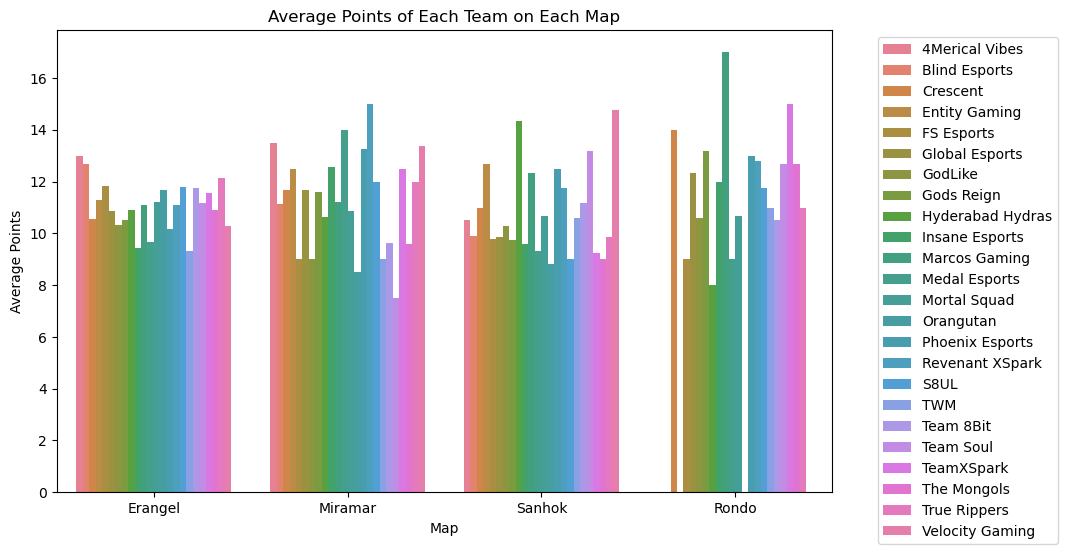

In [69]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Total points banao (agar pehle nahi banaya)
df['total_points'] = df['kills'] + df['placement']

# Step 2: Average points per team per map
avg_points = df.groupby(['team_name', 'map'])['total_points'].mean().reset_index()

# Step 3: Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_points,
    x='map',
    y='total_points',
    hue='team_name'
)

plt.title("Average Points of Each Team on Each Map")
plt.xlabel("Map")
plt.ylabel("Average Points")

plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

- This graph clearly shows that some teams are consistent across all maps, while others perform well only on specific maps.   
Top-performing teams (like TeamXSpark, GodLike, Marcos Gaming) generally score higher on Rondo and Miramar, which suggests they are aggressive and adaptable.
Some teams maintain stable scores on Erangel (around 10–12), indicating a balanced gameplay style.
On Sanhok, many teams struggle, and only a few manage to score high, showing that this map highlights skill differences.   
Some teams show large fluctuations in performance, which means their strategy is not strong across all maps.

 Deep insight: Consistent teams are overall stronger, while map-specific teams need improvement.

# Multivariate Analysis – The Hidden Interactions

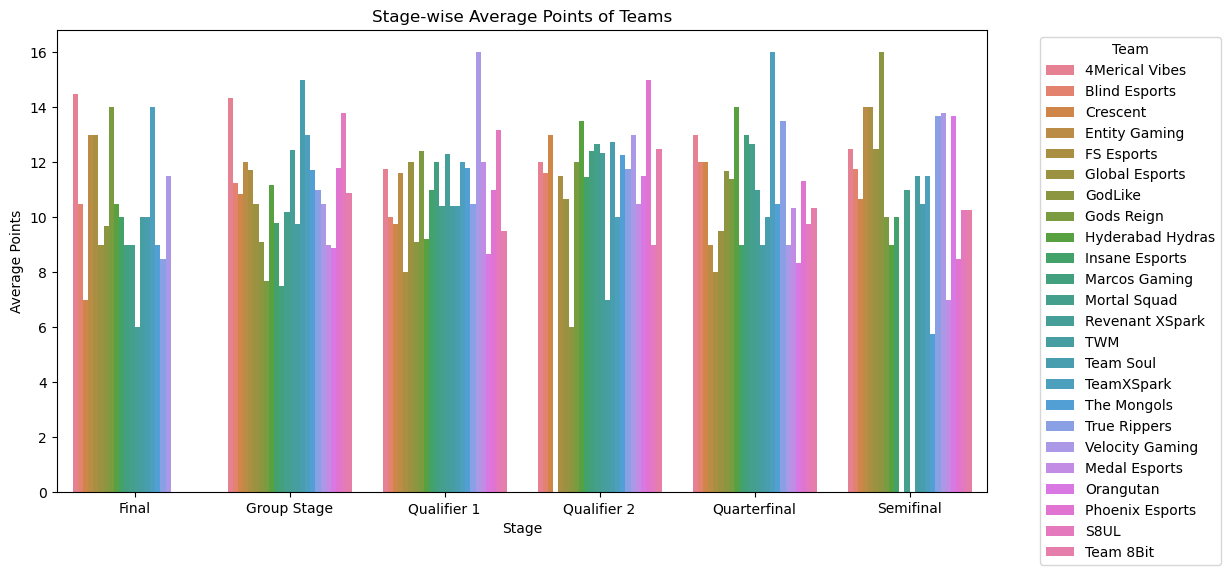

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by stage and team, then calculate average points
stage_team_avg = df.groupby(['stage', 'team_name'])['total_points'].mean().reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=stage_team_avg,
    x='stage',
    y='total_points',
    hue='team_name'
)

plt.title("Stage-wise Average Points of Teams")
plt.xlabel("Stage")
plt.ylabel("Average Points")
plt.legend(title="Team", bbox_to_anchor=(1.05, 1))

plt.show()

- The graph shows stage-wise average points of different BGMI teams.
Top teams like TeamXSpark, GodLike, and Marcos Gaming perform consistently with 12–15+ points.
Teams such as Team Soul, Revenant XSpark, and Orangutan show fluctuating performance.
Lower teams like Blind Esports, 4Merical Vibes, and Crescent stay mostly below 10 points.
In the Group Stage, most teams score in the 10–13 range.
Qualifier 1 and 2 show high variation, with some teams peaking at 15–16 points.
Quarterfinal and Semifinal stages are the most competitive.
Top teams clearly dominate in these middle stages.
In the Final, average points slightly decrease due to pressure.
Overall, consistency across all stages leads to better performance.


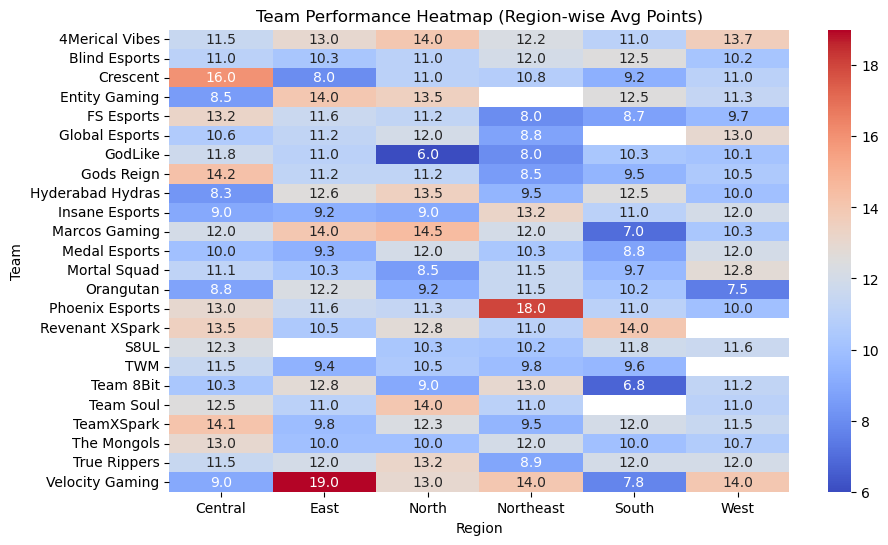

In [32]:
pivot_table = df.pivot_table(
    values='total_points',
    index='team_name',
    columns='region',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="coolwarm")

plt.title("Team Performance Heatmap (Region-wise Avg Points)")
plt.xlabel("Region")
plt.ylabel("Team")

plt.show()

- This heatmap shows **region-wise average points of teams**, helping identify where each team performs best or struggles.

Top teams like TeamXSpark, GodLike, and Marcos Gaming show balanced performance across most regions.
Velocity Gaming has the highest spike (19) in the East region, showing strong dominance there.
Phoenix Esports performs exceptionally in the Northeast (~18 points).
Crescent performs very well in Central (16) but drops in other regions.
Entity Gaming is strong in East and North but weaker in Central.
Some teams like Blind Esports and 4Merical Vibes show average performance across all regions.
A few teams have low scores (6–9) in certain regions, showing clear weaknesses.
The heatmap highlights that **no team dominates every region completely**.
Performance varies significantly based on region/map conditions.
Overall, teams with balanced scores across all regions are the most consistent and reliable.


# 📊 Exploratory Data Analysis (EDA) Report
# BGIS Tournament Performance Dataset

---

# 1. Introduction

The objective of this Exploratory Data Analysis (EDA) is to understand the performance patterns of teams participating in the Battlegrounds Mobile India Series (BGIS). The dataset contains match-level information including kills, placement, damage, maps, tournament stages, and team performance metrics. Through statistical summaries and visualizations, the analysis identifies important trends, relationships, and factors influencing team success.

Exploratory Data Analysis (EDA) is a crucial step before building machine learning models because it helps identify missing values, detect outliers, understand feature distributions, discover hidden relationships, and improve overall data quality. The insights generated during EDA also assist in feature engineering and model selection.

---

# 2. Dataset Overview

The dataset consists of approximately **1000 match records** and **11 features**, where each row represents the performance of a team in a single BGIS match.

## Dataset Features

| Feature | Description |
|----------|-------------|
| Match ID | Unique identifier of each match |
| Team | Name of the participating team |
| Map | Map played during the match |
| Stage | Tournament stage |
| Placement | Final team ranking |
| Kills | Number of enemy eliminations |
| Damage | Total damage dealt |
| Placement Points | Points earned from final placement |
| Total Points | Overall tournament points |

The dataset contains both numerical and categorical variables, making it suitable for descriptive statistics, visualization, and predictive modeling.

---

# 3. Data Cleaning and Preprocessing

High-quality analysis requires clean and reliable data. Several preprocessing steps were performed before visualization.

## Removal of Incorrect Points

The original **Points** column contained inconsistent values that did not correctly represent the official BGIS scoring system.

To avoid misleading analysis, the incorrect column was removed and replaced with a newly calculated **Total Points** feature.

---

## Removal of Vikendi Map

The **Vikendi** map was excluded from the analysis because it is not part of the standard BGIS competitive tournament map pool.

Removing this map ensures consistency across all tournament matches and avoids introducing unnecessary bias.

---

## Placement Outlier Removal

Some records contained placement values greater than **10**, which are invalid for the tournament format.

These records were treated as outliers and removed to improve statistical reliability.

Benefits of this cleaning step include:

- Improved data consistency
- Reduced statistical bias
- Better visualization accuracy
- More reliable model training

---

## Feature Engineering

A new feature called **Total Points** was created using the official BGIS scoring system.

**Formula**

```text
Total Points = Placement Points + Kill Points
```

This engineered feature provides a more accurate representation of overall team performance.

---

# 4. Univariate Analysis

Univariate analysis focuses on understanding the distribution of individual variables.

## Total Points Distribution

The histogram shows that most teams score between **10 and 14 points**.

### Observations

- Moderate scores dominate the tournament.
- Extremely high scores are uncommon.
- Very low scores occur less frequently.
- Distribution appears approximately bell-shaped.

### Interpretation

This indicates that the tournament is highly competitive, with most teams performing within a similar scoring range.

---

## Placement Distribution

Placement values range from **1 to 10**.

### Observations

- No placement dominates the distribution.
- Middle placements occur slightly more often.
- Winning positions remain relatively rare.

### Interpretation

The tournament demonstrates a balanced level of competition where teams frequently change rankings between matches.

---

## Kill Distribution

Kills are concentrated around **5–7 eliminations**.

### Observations

- Average kills ≈ 6
- High-kill matches are uncommon.
- Very few teams finish without kills.
- Distribution is slightly right-skewed.

### Interpretation

Most successful teams adopt balanced aggression instead of relying solely on eliminations.

---

## Damage Distribution

Damage values exhibit moderate variation.

### Observations

- Most teams deal medium damage.
- Extremely high damage matches are rare.
- Damage distribution contains few outliers.

### Interpretation

Damage reflects consistent combat engagement and serves as an important indicator of team activity.

---

# 5. Bivariate Analysis

Bivariate analysis examines relationships between two variables.

## Placement vs Total Points

A strong positive relationship exists between placement and total points.

### Findings

- Better placements consistently earn higher scores.
- Placement contributes significantly to tournament success.
- High kills alone cannot compensate for poor placement.

### Interpretation

This confirms that survival remains one of the most important components of the BGIS scoring system.

---

## Map-wise Performance

Average team performance varies across maps.

### Findings

- Rondo produces the highest average points.
- Erangel and Miramar show similar average performance.
- Sanhok records comparatively lower scores.

### Interpretation

Different maps encourage different playstyles, rotations, and combat strategies.

---

## Team Performance Across Maps

Several teams demonstrate map-specific strengths.

Examples include:

- Marcos Gaming performs exceptionally well on Rondo.
- Revenant XSpark dominates Miramar.
- 4Merical Vibes performs strongly on Erangel.
- Velocity Gaming performs well on Sanhok.

### Interpretation

Professional teams adapt their strategies according to map characteristics.

---

# 6. Multivariate Analysis

Multivariate analysis explores interactions among multiple variables simultaneously.

## Stage-wise Team Performance

Performance varies across tournament stages.

### Findings

Top-performing teams maintain consistent scores throughout the competition, including:

- Team XSpark
- GodLike
- Marcos Gaming
- Blind Esports

Lower-ranked teams show greater fluctuations.

### Interpretation

Experienced teams demonstrate stronger adaptability and consistency under competitive pressure.

---

## Team vs Map Heatmap

The heatmap highlights performance differences across teams and maps.

### Findings

- Certain teams consistently dominate specific maps.
- Performance varies according to terrain and strategy.
- Elite teams maintain high scores regardless of map.

### Interpretation

Map specialization is an important competitive advantage.

---

## Team Performance Patterns

Successful teams generally combine:

- High kills
- Good placement
- High damage
- Consistent scoring

### Interpretation

Balanced gameplay is more effective than relying solely on aggressive or defensive strategies.

---

# 7. Correlation Analysis

Correlation analysis measures the relationship between numerical variables.

## Major Relationships

| Variables | Relationship |
|------------|-------------|
| Placement ↔ Total Points | Strong Positive |
| Kills ↔ Total Points | Positive |
| Damage ↔ Kills | Positive |
| Placement Points ↔ Total Points | Strong Positive |

### Interpretation

Teams that survive longer while securing eliminations consistently achieve higher tournament scores.

---

# 8. Key Findings

## Tournament Competitiveness

The majority of teams score within a similar range, indicating a highly competitive tournament.

---

## Placement is Critical

Better placement contributes significantly more to tournament success than aggressive gameplay alone.

---

## Importance of Kills

Kills increase total points, but must be supported by good survival strategy.

---

## Map Strategy Matters

Different battlegrounds require different tactical approaches.

Teams should customize rotations and engagements according to map characteristics.

---

## Consistency Wins Championships

Elite teams consistently perform well across different maps and tournament stages rather than relying on isolated high-scoring matches.

---

## Damage Reflects Team Activity

Although damage does not directly contribute to tournament points, it strongly correlates with kills and overall performance.

---

# 9. Recommendations

Based on the EDA findings, the following recommendations can improve team performance:

- Focus on improving placement consistency.
- Balance aggressive gameplay with survival.
- Develop map-specific practice sessions.
- Analyze damage alongside kills.
- Monitor performance trends across tournament stages.
- Use historical data for future performance prediction.

---

# 10. Limitations

This analysis has several limitations.

- The dataset represents only one tournament.
- Player-level statistics are unavailable.
- Circle location and loot quality are not included.
- Environmental factors are absent.
- Some relationships may differ in future BGIS seasons.

---

# 11. Future Scope

The project can be extended through machine learning and advanced analytics.

Possible future work includes:

- Predict Total Points using regression models.
- Predict tournament winners using classification algorithms.
- Cluster teams based on playstyle.
- Build Power BI dashboards.
- Develop win probability prediction models.
- Analyze player-level performance metrics.
- Create interactive esports analytics dashboards.

---

# 12. Conclusion

The Exploratory Data Analysis successfully transformed raw BGIS tournament data into meaningful competitive insights. Data cleaning improved dataset quality by removing inconsistencies and invalid records, while feature engineering created a more accurate representation of the official BGIS scoring system.

The analysis revealed that **placement, kills, and damage are the strongest indicators of team performance**, with placement contributing the most to total points. Map-specific trends demonstrated that different battlegrounds require different tactical approaches, while multivariate analysis showed that elite teams maintain consistent performance across tournament stages and maps.

Overall, this EDA provides valuable insights into competitive gameplay, identifies important performance drivers, and establishes a strong foundation for future machine learning models, predictive analytics, esports performance evaluation, and strategic decision-making.